# June 3, 2026 Notes and Code

### Activity 

For each visualization, discuss the following questions:
- What information can we learn from this vsualization?
- Is this an example of objective, neutral data visualization? Why or why not?

##### Visualization #1: US Gun Killings
- we know number of people dying in gunkillings
- it provides ages of victims of gunkillings
- is provides estimated difference in lifespan
- not very neutral though, because it projects/guesses remaining lifespan, which is impossible to know
- generates emotional response
- color change when death of an individual happens
- wordchoice of "stolen" is rhetorical

##### Visualization #2: Washington Post Active Shooters
- shows increase in number of shooters over time
- more objective and neutral than the last
- uses neutral color palette
- does not use vocabulary to spark emotional reaction
- just a bit unclear in definition of active shooter
- clear and easily understood
- but more clarity needed re. definition of "active shooters" 

### Activity: Exploring matplotlib

visualization chosen: animated bubble chart
https://python-graph-gallery.com/341-python-gapminder-animation/

In [8]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
import numpy as np

data = pd.read_csv('https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/gapminderData.csv')
data['continent'] = pd.Categorical(data['continent'])
data.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


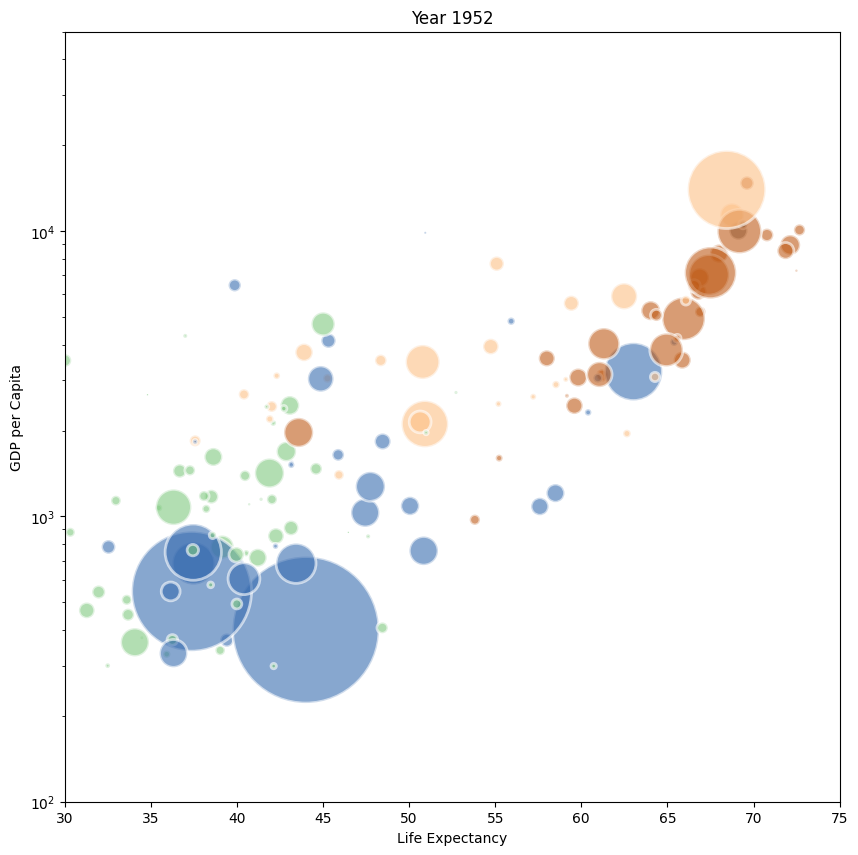

In [19]:
fig, ax = plt.subplots(figsize=(10, 10))

# Subset of the data for year 1952
data1952 = data[data.year == 1952]

# Scatterplot
ax.scatter(
    x = data1952['lifeExp'], 
    y = data1952['gdpPercap'], 
    s = data1952['pop']/50000, 
    c = data1952['continent'].cat.codes, 
    cmap = "Accent", 
    alpha = 0.6, 
    edgecolors = "white", 
    linewidth = 2
)
 
# Add titles (main and on axis)
plt.yscale('log')
ax.set_xlabel("Life Expectancy")
ax.set_ylabel("GDP per Capita")
ax.set_title("Year 1952")
ax.set_ylim(100,50000)
ax.set_xlim(30, 75)

plt.show()

##### Animated Bubble Chart

In [20]:
interp_data = pd.DataFrame()

multiple = 10
for country in data['country'].unique():
   
   # prepare a temporary dataframe and subset
   temp_df = pd.DataFrame()
   country_df = data[data['country']==country]

   # interpolate the data
   years = np.linspace(country_df['year'].min(), country_df['year'].max(), len(country_df) * multiple-(multiple-1))
   pops = np.linspace(country_df['pop'].min(), country_df['pop'].max(), len(country_df) * multiple-(multiple-1))
   lifeExps = np.linspace(country_df['lifeExp'].min(), country_df['lifeExp'].max(), len(country_df) * multiple-(multiple-1))
   gdps = np.linspace(country_df['gdpPercap'].min(), country_df['gdpPercap'].max(), len(country_df) * multiple-(multiple-1))
   continents = [country_df['continent'].values[0]] * len(years)

   # add the data to the temporary dataframe
   temp_df['year'] = years
   temp_df['pop'] = pops
   temp_df['lifeExp'] = lifeExps
   temp_df['gdpPercap'] = gdps
   temp_df['continent'] = continents
   temp_df['country'] = country

   # append the temporary dataframe to the final dataframe
   interp_data = pd.concat([interp_data, temp_df])
   interp_data['continent'] = pd.Categorical(interp_data['continent'])

interp_data.head()

,year,pop,lifeExp,gdpPercap,continent,country
0,1952.0,8.425333e+06,28.801000,635.341351,Asia,Afghanistan
1,1952.5,8.638647e+06,28.937609,638.456534,Asia,Afghanistan
2,1953.0,8.851962e+06,29.074218,641.571716,Asia,Afghanistan
3,1953.5,9.065276e+06,29.210827,644.686899,Asia,Afghanistan
4,1954.0,9.278591e+06,29.347436,647.802081,Asia,Afghanistan


MovieWriter ffmpeg unavailable; using Pillow instead.


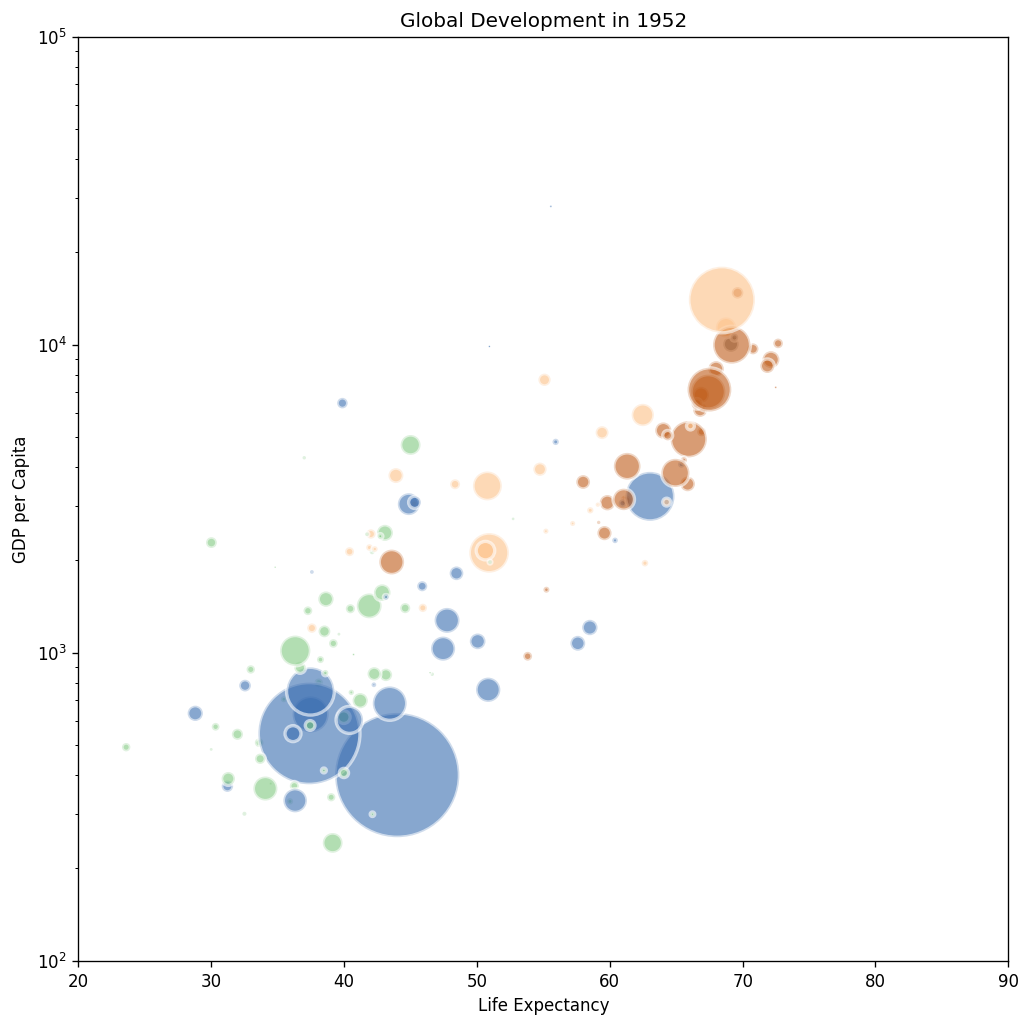

In [21]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=120)

def update(frame):
    # Clear the current plot to redraw
    ax.clear()
    
    # Filter data for the specific year
    yearly_data = interp_data.loc[interp_data.year == frame, :]

    # Scatter plot for that year
    ax.scatter(
        x=yearly_data['lifeExp'], 
        y=yearly_data['gdpPercap'], 
        s=yearly_data['pop']/100000,
        c=yearly_data['continent'].cat.codes, 
        cmap="Accent", 
        alpha=0.6, 
        edgecolors="white", 
        linewidths=2
    )

    # Updating titles and layout
    ax.set_title(f"Global Development in {round(frame)}")
    ax.set_xlabel("Life Expectancy")
    ax.set_ylabel("GDP per Capita")
    ax.set_yscale('log')
    ax.set_ylim(100, 100000)
    ax.set_xlim(20, 90)

    return ax

ani = FuncAnimation(fig, update, frames=interp_data['year'].unique())
ani.save('/Users/charissachan/Desktop/DSI/visualization/02_activities/assignments/participation/gapminder-1.gif', fps=10)

Note: See "gapminder-1.gift" file for animation

##### Observations
- fairly pleasing to look at -- color scheme is muted and not overwhelming
- smoothness of animation also contributes to pleasing visual
- suggests a positive correlation between GDP per capita and life expectancy of a country's population
- also reveals the relative population of each country by the size of the bubbles
- the representation of data is accurate and honest
- however, it does not have legend, so what each country the colors correspond to could be clearer
- the scaling could be improved, because some of the bubbles are incredibly small and can be easily missed
- labels of each axes are clear and informative